In [1]:
# ============================================================
# EDA + Modelo KNN usando dataset Breast Cancer de scikit-learn
# ============================================================

# 1. Importamos las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay







In [2]:
# ============================================================
# PARTE 1: CARGA DEL DATASET
# ============================================================

# 2. Cargamos el dataset Breast Cancer incluido en scikit-learn
data = load_breast_cancer()

# 3. Convertimos las variables predictoras en un DataFrame
df = pd.DataFrame(data.data, columns=data.feature_names)




In [3]:
df.head(10)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,0.07613,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,0.05742,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,0.07451,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,0.07389,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,0.08243,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [4]:
# 4. Agregamos la variable objetivo al DataFrame
df["diagnostico"] = data.target

# 5. Creamos una versión con nombres más claros para la variable objetivo
df["diagnostico_nombre"] = df["diagnostico"].map({
    0: "maligno",
    1: "benigno"
})


In [5]:
# ============================================================
# PARTE 2: EXPLORACIÓN INICIAL DEL DATASET
# ============================================================

# 6. Mostramos las primeras filas del dataset
print("Primeras filas del dataset:")
print(df.head())

# 7. Revisamos el tamaño del dataset
print("\nTamaño del dataset:")
print(df.shape)

# 8. Revisamos los nombres de las columnas
print("\nColumnas del dataset:")
print(df.columns)

# 9. Revisamos información general del dataset
print("\nInformación general del dataset:")
print(df.info())

# 10. Revisamos estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(df.describe())

# 11. Revisamos valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# 12. Revisamos filas duplicadas
print("\nCantidad de filas duplicadas:")
print(df.duplicated().sum())


Primeras filas del dataset:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst perimeter  worst area  wor


Distribución del diagnóstico:
diagnostico_nombre
benigno    357
maligno    212
Name: count, dtype: int64


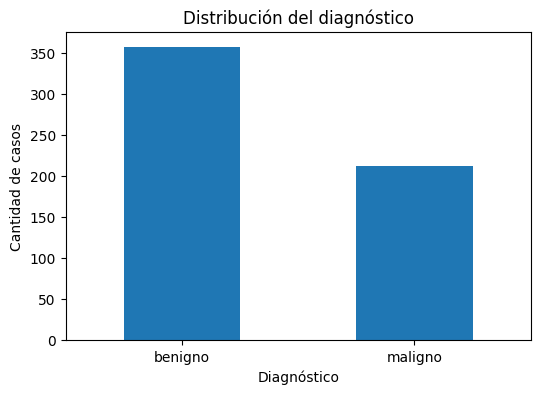

In [6]:
# ============================================================
# PARTE 3: ANÁLISIS DE LA VARIABLE OBJETIVO
# ============================================================

# 13. Revisamos la distribución de la variable objetivo
print("\nDistribución del diagnóstico:")
print(df["diagnostico_nombre"].value_counts())

# 14. Graficamos la distribución del diagnóstico
plt.figure(figsize=(6, 4))
df["diagnostico_nombre"].value_counts().plot(kind="bar")
plt.title("Distribución del diagnóstico")
plt.xlabel("Diagnóstico")
plt.ylabel("Cantidad de casos")
plt.xticks(rotation=0)
plt.show()

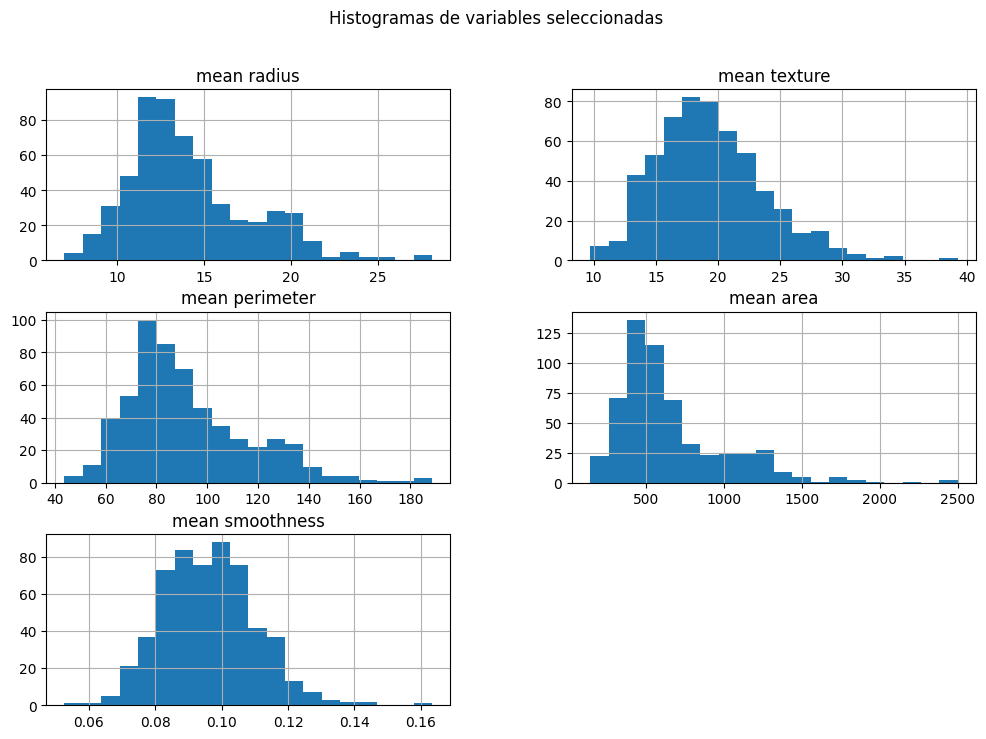

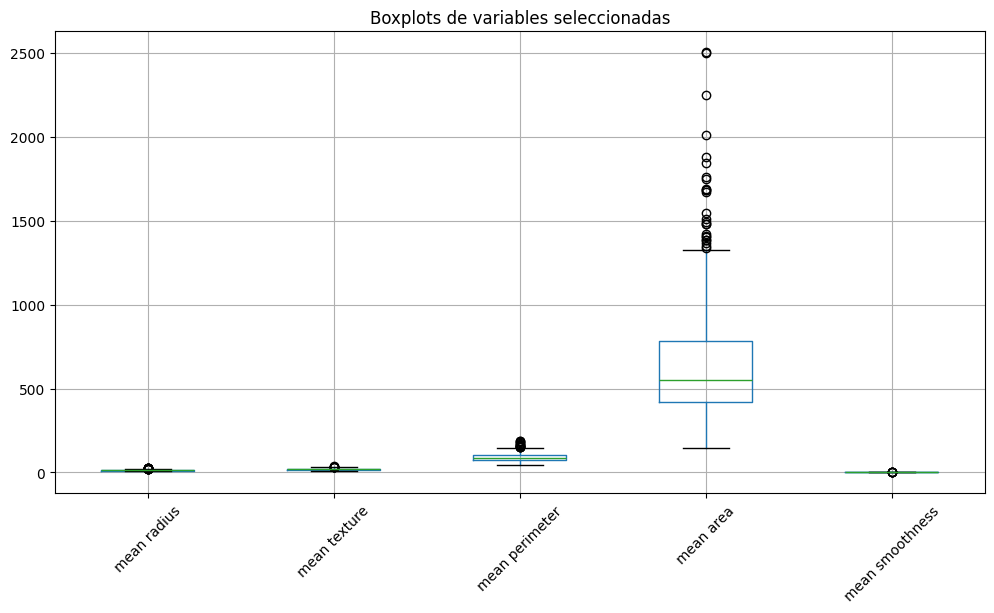

<Figure size 700x500 with 0 Axes>

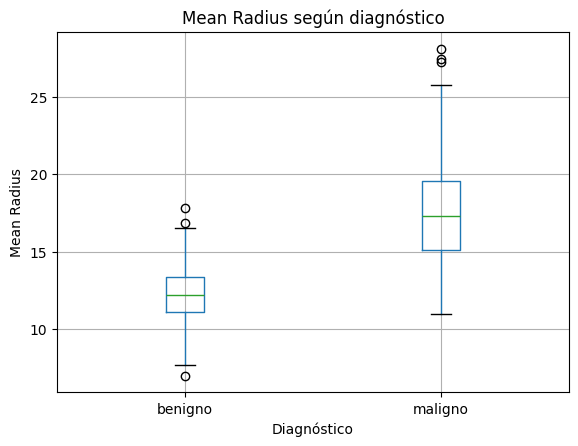

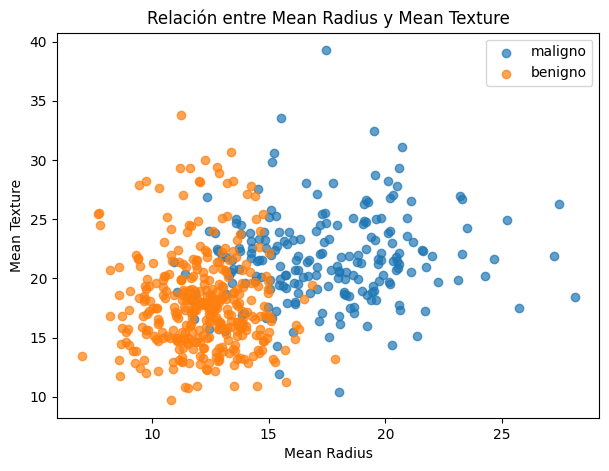

In [7]:
# ============================================================
# PARTE 4: ANÁLISIS DE VARIABLES NUMÉRICAS
# ============================================================

# 15. Seleccionamos algunas variables para que el análisis sea más fácil de leer
variables_interes = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

# 16. Graficamos histogramas de algunas variables
df[variables_interes].hist(figsize=(12, 8), bins=20)
plt.suptitle("Histogramas de variables seleccionadas")
plt.show()

# 17. Graficamos boxplots para detectar posibles valores extremos
plt.figure(figsize=(12, 6))
df[variables_interes].boxplot()
plt.title("Boxplots de variables seleccionadas")
plt.xticks(rotation=45)
plt.show()

# 18. Comparamos una variable entre diagnósticos
plt.figure(figsize=(7, 5))
df.boxplot(column="mean radius", by="diagnostico_nombre")
plt.title("Mean Radius según diagnóstico")
plt.suptitle("")
plt.xlabel("Diagnóstico")
plt.ylabel("Mean Radius")
plt.show()

# 19. Graficamos dos variables para observar separación entre clases
plt.figure(figsize=(7, 5))

for diagnostico in df["diagnostico_nombre"].unique():
    subset = df[df["diagnostico_nombre"] == diagnostico]
    plt.scatter(
        subset["mean radius"],
        subset["mean texture"],
        label=diagnostico,
        alpha=0.7
    )

plt.title("Relación entre Mean Radius y Mean Texture")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.legend()
plt.show()


In [ ]:

# ============================================================
# PARTE 5: MATRIZ DE CORRELACIÓN
# ============================================================

# 20. Calculamos la correlación usando solo variables numéricas
correlacion = df.drop("diagnostico_nombre", axis=1).corr()

# 21. Mostramos correlaciones con la variable objetivo
print("\nCorrelación con el diagnóstico:")
print(correlacion["diagnostico"].sort_values(ascending=False))

# 22. Visualizamos una matriz de correlación simplificada
plt.figure(figsize=(10, 8))
plt.imshow(correlacion, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.title("Matriz de correlación")
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=90, fontsize=6)
plt.yticks(range(len(correlacion.columns)), correlacion.columns, fontsize=6)
plt.show()

In [ ]:
# ============================================================
# PARTE 6: PREPARACIÓN DE DATOS PARA KNN
# ============================================================

# 23. Definimos X con las variables predictoras
X = df.drop(["diagnostico", "diagnostico_nombre"], axis=1)

# 24. Definimos y con la variable objetivo
y = df["diagnostico"]

# 25. Dividimos el dataset en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# 26. Escalamos los datos porque KNN trabaja con distancias
scaler = StandardScaler()

# 27. Ajustamos el escalador solo con los datos de entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# 28. Aplicamos el mismo escalador a los datos de prueba
X_test_scaled = scaler.transform(X_test)



In [ ]:
# ============================================================
# PARTE 7: ENTRENAMIENTO DEL MODELO KNN
# ============================================================

# 29. Creamos un modelo KNN con 5 vecinos
knn = KNeighborsClassifier(n_neighbors=5)

# 30. Entrenamos el modelo con los datos de entrenamiento
knn.fit(X_train_scaled, y_train)

# 31. Hacemos predicciones con los datos de prueba
y_pred = knn.predict(X_test_scaled)

In [ ]:
# ============================================================
# PARTE 8: EVALUACIÓN DEL MODELO
# ============================================================

# 32. Calculamos el accuracy del modelo
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy del modelo KNN:")
print(round(accuracy, 4))

# 33. Mostramos el reporte de clasificación
print("\nReporte de clasificación:")
print(classification_report(
    y_test,
    y_pred,
    target_names=data.target_names
))

# 34. Creamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de confusión:")
print(cm)

# 35. Visualizamos la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Matriz de Confusión - KNN")
plt.show()


# ============================================================
# PARTE 9: COMPARACIÓN DE DIFERENTES VALORES DE K
# ============================================================

# 36. Creamos una lista de valores de K para probar
valores_k = range(1, 21)

# 37. Creamos una lista para guardar los resultados
resultados_accuracy = []

# 38. Entrenamos un modelo KNN para cada valor de K
for k in valores_k:
    modelo = KNeighborsClassifier(n_neighbors=k)
    modelo.fit(X_train_scaled, y_train)
    predicciones = modelo.predict(X_test_scaled)
    acc = accuracy_score(y_test, predicciones)
    resultados_accuracy.append(acc)

# 39. Graficamos el accuracy para cada valor de K
plt.figure(figsize=(8, 5))
plt.plot(valores_k, resultados_accuracy, marker="o")
plt.title("Accuracy según el valor de K")
plt.xlabel("Número de vecinos K")
plt.ylabel("Accuracy")
plt.xticks(valores_k)
plt.grid(True)
plt.show()

# 40. Identificamos el mejor valor de K
mejor_k = valores_k[np.argmax(resultados_accuracy)]
mejor_accuracy = max(resultados_accuracy)

print("\nMejor valor de K:")
print(mejor_k)

print("\nMejor accuracy:")
print(round(mejor_accuracy, 4))


# ============================================================
# PARTE 10: EJEMPLO DE PREDICCIÓN CON UN NUEVO CASO
# ============================================================

# 41. Tomamos un caso del dataset de prueba como ejemplo
nuevo_caso = X_test.iloc[[0]]

# 42. Escalamos el nuevo caso usando el mismo scaler
nuevo_caso_scaled = scaler.transform(nuevo_caso)

# 43. Realizamos la predicción
prediccion = knn.predict(nuevo_caso_scaled)

# 44. Convertimos la predicción en texto
resultado = "benigno" if prediccion[0] == 1 else "maligno"

print("\nPredicción para un nuevo caso:")
print(resultado)